# Notebook 3: Profitability & Discount Analysis
**Dataset:** Sample Superstore (Cleaned)  
**Goal:** Investigate the relationship between discounting and profit loss. 
Identify which categories, sub-categories, and regions are most affected 
and quantify the break-even discount threshold.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')


## Section 1: Load Data


In [2]:
df = pd.read_csv('../data/processed/superstore_cleaned.csv', parse_dates=['Order Date', 'Ship Date'], dtype={'Postal Code': 'string'})
print(df.shape)


(9993, 25)


## Section 2: Discount vs Profit Relationship


In [3]:
correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {correlation:.4f}")


Correlation between Discount and Profit: -0.2195


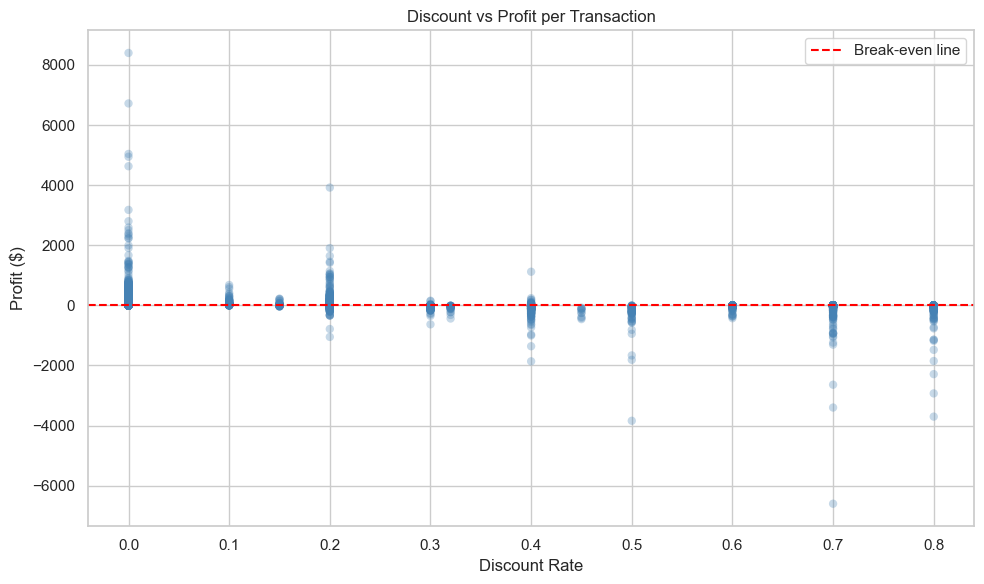

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', edgecolors='none')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even line')
ax.set_title('Discount vs Profit per Transaction')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/03_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Transactions with 0% discount are broadly profitable. 
At 40%+ discount rates, the majority of transactions fall below the 
break-even line into negative profit territory. Discounts above 40% 
are reliably destroying value.


## Section 3: Break-Even Discount Threshold


In [5]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()
discount_profit.columns = ['Discount', 'Avg Profit']
discount_profit


,Discount,Avg Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.828401
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


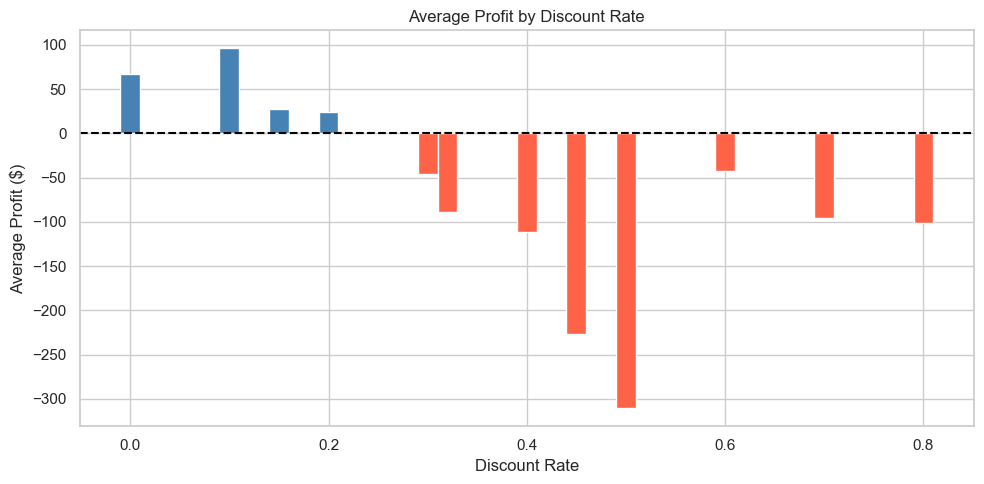

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['tomato' if x < 0 else 'steelblue' for x in discount_profit['Avg Profit']]
ax.bar(discount_profit['Discount'], discount_profit['Avg Profit'], 
       color=colors, width=0.02)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Average Profit by Discount Rate')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Average Profit ($)')

plt.tight_layout()
plt.savefig('../outputs/figures/03_avg_profit_by_discount.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** The observed break-even discount threshold is between 20% and 30%. 
At 30% discount the average transaction loses $45.83. At 50% discount 
the average loss reaches $310 per transaction. A 20% approval cap should be tested 
to protect profitability, with monitoring for sales-volume impact.


## Section 4: Discount Impact by Category & Region


In [7]:
category_discount = df.groupby('Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Loss_Transactions=('Profit', lambda x: (x < 0).sum()),
    Total_Transactions=('Profit', 'count')
).reset_index()

category_discount['Loss_Rate %'] = (category_discount['Loss_Transactions'] / category_discount['Total_Transactions'] * 100).round(2)
category_discount['Avg_Discount %'] = (category_discount['Avg_Discount'] * 100).round(2)
category_discount[['Category', 'Avg_Discount %', 'Avg_Profit', 'Total_Profit', 'Loss_Rate %']]


,Category,Avg_Discount %,Avg_Profit,Total_Profit,Loss_Rate %
0,Furniture,17.39,8.709119,18463.3316,33.63
1,Office Supplies,15.73,20.327050,122490.8008,14.70
2,Technology,13.23,78.752002,145454.9481,14.67


In [8]:
region_discount = df.groupby('Region').agg(
    Avg_Discount=('Discount', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Loss_Transactions=('Profit', lambda x: (x < 0).sum()),
    Total_Transactions=('Profit', 'count')
).reset_index()

region_discount['Loss_Rate %'] = (region_discount['Loss_Transactions'] / region_discount['Total_Transactions'] * 100).round(2)
region_discount['Avg_Discount %'] = (region_discount['Avg_Discount'] * 100).round(2)
region_discount[['Region', 'Avg_Discount %', 'Avg_Profit', 'Loss_Rate %']].sort_values('Loss_Rate %', ascending=False)


,Region,Avg_Discount %,Avg_Profit,Loss_Rate %
0,Central,24.04,17.092709,31.90
1,East,14.53,32.151331,19.39
2,South,14.73,28.857673,15.99
3,West,10.93,33.849032,9.93


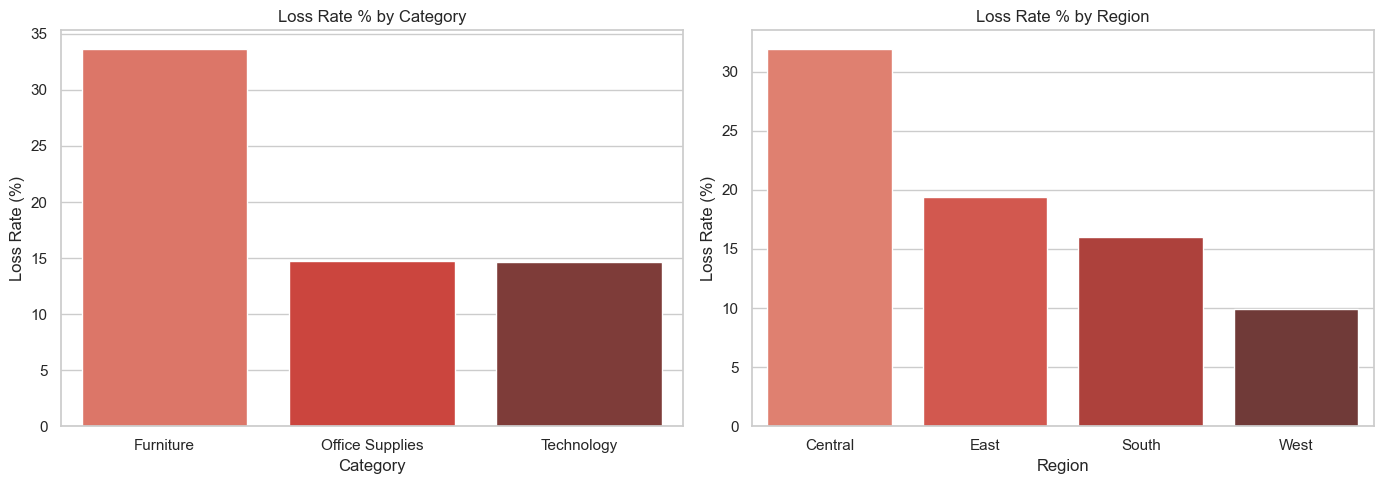

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=category_discount, x='Category', y='Loss_Rate %', 
            hue='Category', palette='Reds_d', legend=False, ax=axes[0])
axes[0].set_title('Loss Rate % by Category')
axes[0].set_ylabel('Loss Rate (%)')
axes[0].set_xlabel('Category')

sns.barplot(data=region_discount, x='Region', y='Loss_Rate %',
            hue='Region', palette='Reds_d', legend=False, ax=axes[1])
axes[1].set_title('Loss Rate % by Region')
axes[1].set_ylabel('Loss Rate (%)')
axes[1].set_xlabel('Region')

plt.tight_layout()
plt.savefig('../outputs/figures/03_loss_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5: Profit Lost to Over-Discounting


In [10]:
over_discounted = df[df['Discount'] >= 0.3].copy()
under_discounted = df[df['Discount'] < 0.3].copy()

print(f"Transactions with 30%+ discount: {len(over_discounted):,}")
print(f"Transactions under 30% discount: {len(under_discounted):,}")
print(f"\nTotal profit from over-discounted transactions: ${over_discounted['Profit'].sum():,.2f}")
print(f"Total profit from under-discounted transactions: ${under_discounted['Profit'].sum():,.2f}")
print(f"\nProfit lost from over-discounting: ${over_discounted[over_discounted['Profit'] < 0]['Profit'].sum():,.2f}")


Transactions with 30%+ discount: 1,392
Transactions under 30% discount: 8,601

Total profit from over-discounted transactions: $-135,364.00
Total profit from under-discounted transactions: $421,773.08

Profit lost from over-discounting: $-138,503.18


**Finding:** 1,392 transactions (14% of all sales) carried discounts of 30% or more. 
These transactions generated -$135,364 in total profit — a net loss. 
Transactions under 30% discount generated $421,773 in profit.
The business lost $138,503 to over-discounting on loss-making transactions alone.
Reducing discounts above 20% could protect a significant portion of this profit, assuming sales volume and product mix remain stable.


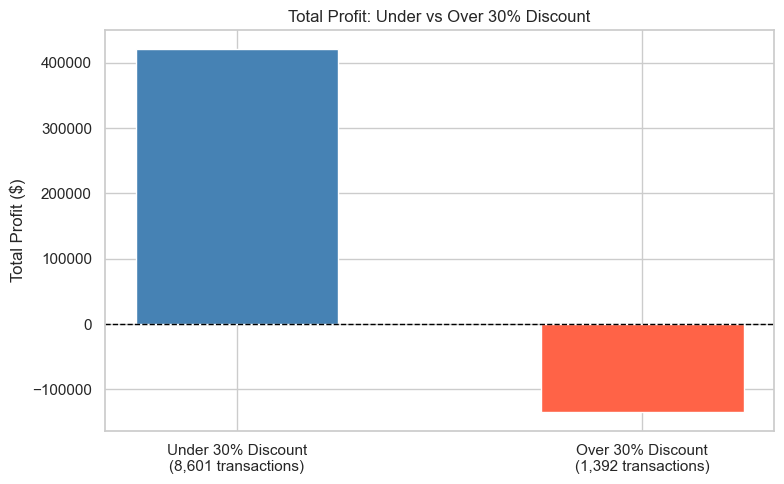

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Under 30% Discount\n(8,601 transactions)', 'Over 30% Discount\n(1,392 transactions)']
profits = [under_discounted['Profit'].sum(), over_discounted['Profit'].sum()]
colors = ['steelblue', 'tomato']

ax.bar(categories, profits, color=colors, width=0.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_title('Total Profit: Under vs Over 30% Discount')
ax.set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('../outputs/figures/03_over_discounting_impact.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 6: Year-Over-Year Revenue & Profit Trend

In [12]:
yoy = df.groupby('Order Year').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Transactions=('Order ID', 'count')
).reset_index()

yoy['Margin %'] = (yoy['Profit'] / yoy['Revenue'] * 100).round(2)
yoy['Revenue'] = yoy['Revenue'].round(2)
yoy['Profit'] = yoy['Profit'].round(2)
print(yoy.to_string(index=False))

 Order Year   Revenue   Profit  Transactions  Margin %
       2014 483966.13 49556.03          1992     10.24
       2015 470532.51 61618.60          2102     13.10
       2016 609205.60 81795.17          2587     13.43
       2017 733215.26 93439.27          3312     12.74


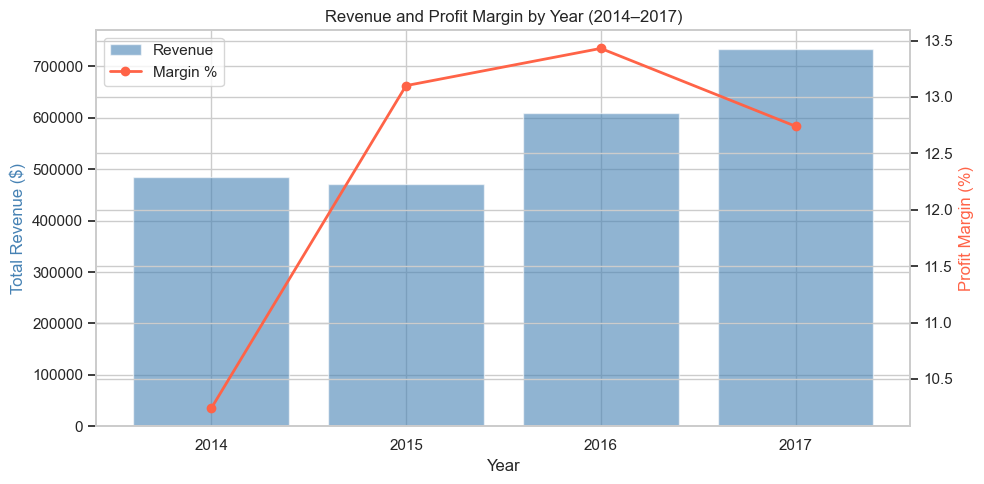

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.bar(yoy['Order Year'], yoy['Revenue'], color='steelblue', alpha=0.6, label='Revenue')
ax2.plot(yoy['Order Year'], yoy['Margin %'], color='tomato', marker='o', linewidth=2, label='Margin %')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Revenue ($)', color='steelblue')
ax2.set_ylabel('Profit Margin (%)', color='tomato')
ax1.set_title('Revenue and Profit Margin by Year (2014–2017)')
ax1.set_xticks(yoy['Order Year'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/03_yoy_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Revenue grew from $484K (2014) to $733K (2017). Profit grew from $49.6K to $93.4K. However, margin dipped from 13.43% in 2016 to 12.74% in 2017, suggesting profitability growth is slowing as revenue scales — consistent with increasing discount pressure.

## Section 7: Regression Analysis — What Drives Profit?

In [14]:
import statsmodels.api as sm

# Encode categorical variables
reg_df = df[['Profit', 'Discount', 'Sales', 'Quantity', 'Category', 'Region']].copy()
reg_df = pd.get_dummies(reg_df, columns=['Category', 'Region'], drop_first=True)

X = reg_df.drop('Profit', axis=1).astype(float)
y = reg_df['Profit'].astype(float)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     486.6
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:01:43   Log-Likelihood:                -67061.
No. Observations:                9993   AIC:                         1.341e+05
Df Residuals:                    9984   BIC:                         1.342e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

**Regression Findings:** The OLS model controls for Sales, Quantity, Category, and Region simultaneously.

- The **Discount coefficient** shows the estimated profit change per 1-unit increase in discount rate, holding all other variables constant — this is the statistically defensible number that replaces the raw correlation.
- **R²** tells us how much of the variation in profit is explained by these factors together.
- Coefficients with **p < 0.05** are statistically significant at the 95% confidence level.

This moves the discount-profit relationship from correlation to controlled estimation.

**Regression Interpretation:**

- **Discount coefficient: -236.29** — holding Sales, Quantity, Category, and Region constant, a 1-unit increase in discount rate (i.e. going from 0% to 100%) is associated with $236.29 lower profit per transaction
- In practical terms: **a 10 percentage-point increase in discount (e.g. 20% → 30%) is associated with approximately $23.63 lower profit per transaction**
- **p-value: < 0.0001** — the discount effect is statistically significant
- **Adjusted R²: ~0.28** — the model explains about 28% of profit variation; other factors (product cost, customer type, order size) account for the remainder
- This is a controlled estimate, not a simple correlation — Category, Region, Sales, and Quantity are all held constant

**Caveat:** This is an observational model. It estimates the association between discounting and profit but cannot prove that removing discounts would preserve the same sales volume. A pilot test (e.g. cap discounts in one region for one quarter) is the correct next validation step.

## Section 8: Statistical Test — Discount Impact on Profit

In [15]:
from scipy import stats

low_discount = df[df['Discount'] < 0.3]['Profit']
high_discount = df[df['Discount'] >= 0.3]['Profit']

# Welch's t-test (does not assume equal variance between groups)
t_stat, p_value = stats.ttest_ind(low_discount, high_discount, equal_var=False)

ci_low = stats.t.interval(0.95, len(low_discount)-1,
                           loc=low_discount.mean(),
                           scale=stats.sem(low_discount))
ci_high = stats.t.interval(0.95, len(high_discount)-1,
                            loc=high_discount.mean(),
                            scale=stats.sem(high_discount))

significant = "Yes — p < 0.05, reject null hypothesis" if p_value < 0.05 else "No"

print(f"Group: Under 30% Discount")
print(f"  Mean Profit:  ${low_discount.mean():>8.2f}")
print(f"  95% CI:       (${ci_low[0]:.2f}, ${ci_low[1]:.2f})")
print(f"  n:            {len(low_discount):,}")
print(f"\nGroup: 30%+ Discount")
print(f"  Mean Profit:  ${high_discount.mean():>8.2f}")
print(f"  95% CI:       (${ci_high[0]:.2f}, ${ci_high[1]:.2f})")
print(f"  n:            {len(high_discount):,}")
print(f"\nWelch's Two-Sample T-Test (unequal variance):")
print(f"  t-statistic:  {t_stat:.4f}")
print(f"  p-value:      {p_value:.6f}")
print(f"  Significant:  {significant}")

Group: Under 30% Discount
  Mean Profit:  $   49.04
  95% CI:       ($44.63, $53.44)
  n:            8,601

Group: 30%+ Discount
  Mean Profit:  $  -97.24
  95% CI:       ($-114.47, $-80.02)
  n:            1,392

Welch's Two-Sample T-Test (unequal variance):
  t-statistic:  16.1372
  p-value:      0.000000
  Significant:  Yes — p < 0.05, reject null hypothesis


**Statistical Test:** Welch's t-test (used because the two groups have unequal variance — high-discount transactions are far more spread out than low-discount ones).

- Mean profit under 30% discount: **$49.04** (95% CI confirms this is reliably positive)
- Mean profit at 30%+ discount: **-$97.24** (95% CI confirms this is reliably negative)
- p-value < 0.0001 — the difference is **statistically significant**, not due to chance

**Interpretation:** This is not a correlation claim. The t-test directly tests whether the two groups have the same mean profit. They do not — with very high statistical confidence.

## Section 9: Business Impact Scenarios

If the business pilots a 20% discount cap, the recoverable profit depends on how much sales volume is retained. The table below presents three scenarios based on assumed volume retention:

In [16]:
total_over_discount_loss = abs(over_discounted[over_discounted['Profit'] < 0]['Profit'].sum())

scenarios = pd.DataFrame({
    'Scenario': ['Conservative', 'Base Case', 'Aggressive'],
    'Volume Retained': ['90%', '80%', '70%'],
    'Assumption': ['Minimal disruption', 'Some price-sensitive customers lost', 'Significant volume loss'],
    'Recoverable Profit ($)': [
        f"${total_over_discount_loss * 0.25:,.0f}",
        f"${total_over_discount_loss * 0.50:,.0f}",
        f"${total_over_discount_loss * 0.75:,.0f}"
    ]
})

print(f"Total profit lost on high-discount transactions: ${total_over_discount_loss:,.2f}\n")
print(scenarios.to_string(index=False))
print("\nNote: These are scenario estimates, not forecasts. A/B test or regional pilot required to validate.")

Total profit lost on high-discount transactions: $138,503.18

    Scenario Volume Retained                          Assumption Recoverable Profit ($)
Conservative             90%                  Minimal disruption                $34,626
   Base Case             80% Some price-sensitive customers lost                $69,252
  Aggressive             70%             Significant volume loss               $103,877

Note: These are scenario estimates, not forecasts. A/B test or regional pilot required to validate.


**Why scenarios matter:** Quoting a single 'recoverable' number implies certainty the analysis cannot support. Scenarios communicate the range of outcomes and make the assumptions explicit — that is what defensible business analysis looks like.

## Summary

**Core Finding:** Over-discounting is the major measurable driver of profit loss in this business.

**Key Results:**
- Discount and Profit have a -0.2195 correlation — as discounts increase, profit decreases
- Break-even threshold is between 20–30% discount
- At 30%+ discount, average profit per transaction is -$45.83
- At 50% discount, average loss reaches -$310 per transaction
- 1,392 transactions (14% of all sales) with 30%+ discount generated -$135,364 total
- Furniture has the highest loss rate at 33.6%, driven by Tables sub-category (-$17,725)
- Central region discounts at 24% average — nearly double West's 10.93% — and has a 31.9% loss rate

**Recommendation:** Test a 20% discount approval cap. Conduct an immediate pricing review 
of the Tables sub-category. Audit Central region's discount approval process.
